In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

### K-Means Clustering: The Intuition

**K-Means** groups similar data points together into **K** clusters.

Think of it like organizing a messy room into **K piles** based on similarity.

```
Before Clustering (Messy Room):
📦 📱 🪑 📦 📱 🪑 📦 📱 🪑 
📱 📦 🪑 📱 📦 🪑 📱 📦 🪑 
📦 📱 🪑 📦 📱 🪑 📦 📱 🪑 
Everything is mixed together! ❌


After Clustering (Organized into K Piles):
📦 📦 📦 📱 📱 📱 🪑 🪑 🪑 
📦 📦 📦 📱 📱 📱 🪑 🪑 🪑 
📦 📦 📦 📱 📱 📱 🪑 🪑 🪑 
Pile 1 Pile 2 Pile 3
(Boxes) (Phones) (Chairs)

In [57]:
# 3 clusters of data
X, y = make_blobs(
    n_samples=300,
    n_features=2,
    centers=3, # 3 clusters
    cluster_std=1.0,
    random_state=42
)

# model
kmeans = KMeans(n_clusters=3, max_iter=1, random_state=42)
kmeans.fit(X) # train model and in future using model to predict we use "fit" but when we want to "predict" and no need to use model in future we use "fit_predict"

labels = kmeans.labels_ # y_pred
centers = kmeans.cluster_centers_
inertia = kmeans.inertia_
silhouette_avg = silhouette_score(X, labels)

In [58]:
silhouette_avg

0.8480303059596955

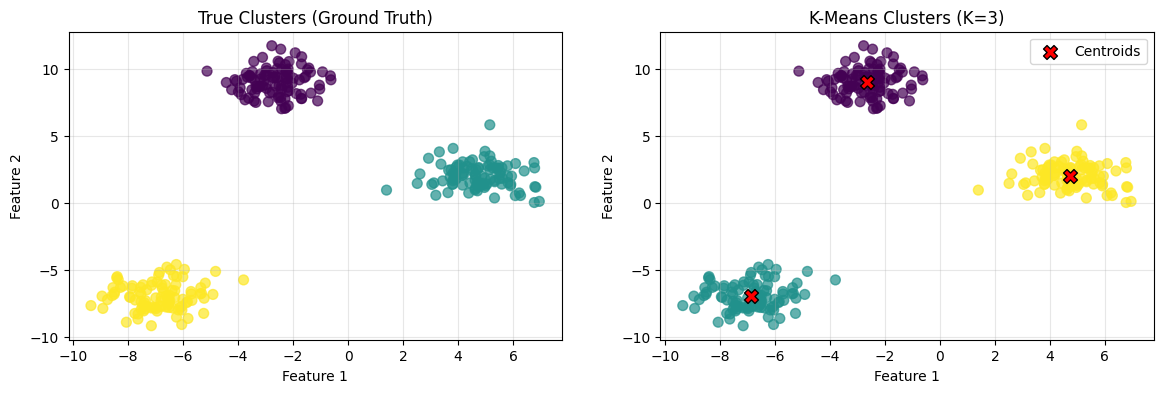

In [23]:
# plot
plt.figure(figsize=(14, 4))

#before cluster
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', s=50, alpha=0.7)
plt.title('True Clusters (Ground Truth)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, alpha=0.3)

# after
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7)
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=100, marker='X', edgecolors='black', linewidths=1, label='Centroids')
plt.title('K-Means Clusters (K=3)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, alpha=0.3)

In [54]:
# find the best cluster
K_range = range(1, 11)
inertias = [] # sum of squares within each cetner
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append((k, kmeans.inertia_))
    
    if k > 1:
        silhouette_scores.append((k, silhouette_score(X, kmeans.labels_)))

silhouette_scores_arr = np.array(silhouette_scores)
best_k = silhouette_scores_arr[np.argmax(np.array(silhouette_scores_arr)[:, 1]), 0]
best_k, silhouette_scores

(np.float64(3.0),
 [(2, 0.7049437310743717),
  (3, 0.8480303059596955),
  (4, 0.6636976714243523),
  (5, 0.49012744554094295),
  (6, 0.5168058221331912),
  (7, 0.358030586983425),
  (8, 0.3625632360122803),
  (9, 0.37134027555333055),
  (10, 0.36060815308421224)])

### Clustering Evaluation Metrics

#### 1. Silhouette Score

$$
\text{Score} = \frac{(b - a)}{\max(a, b)}
$$

**Range:** `[-1, 1]`

| Component | Definition |
|-----------|------------|
| **a** | Mean distance to points in the **same** cluster |
| **b** | Mean distance to points in the **nearest other** cluster |

**Interpretation:**

| Score | Quality |
|-------|---------|
| **> 0.7** | ✅ Good (well-separated clusters) |
| **0.5 - 0.7** | Fair |
| **< 0.5** | ❌ Poor (overlapping clusters) |

> ✅ **Use this as your primary metric!**


#### 2. Inertia (Elbow Method)

$$
\text{Inertia} = \sum \|x - c\|^2
$$

| Rule | Meaning |
|------|---------|
| **Lower** | Better (clusters are tighter) |
| **Always decreases** | With more K |
| **Use for** | Finding the **elbow point** |

> ✅ **Good for choosing K** (when Silhouette isn't clear)


#### 3. Calinski-Harabasz Index

$$
\text{Score} = \frac{SS_{\text{between}}}{SS_{\text{within}}} \times \frac{N - K}{K - 1}
$$

| Rule | Meaning |
|------|---------|
| **Higher** | Better (more separated) |
| **Measures** | Cluster separation and compactness |

> ✅ **Good for comparing different K**

#### 4. Davies-Bouldin Index

$$
\text{Score} = \text{average similarity between clusters}
$$

| Rule | Meaning |
|------|---------|
| **Lower** | Better |
| **0** | Perfect (clusters are completely separated) |

> ✅ **Good for checking cluster overlap**

#### Summary Table

| Metric | Best Value | What It Measures | Use For |
|--------|------------|------------------|---------|
| **Silhouette** | > 0.7 | Separation + Cohesion | **Primary metric** |
| **Inertia** | Lower is better | Cluster compactness | Choosing K (Elbow) |
| **Calinski-Harabasz** | Higher is better | Cluster separation | Comparing K |
| **Davies-Bouldin** | Lower is better | Cluster overlap | Checking overlap |
